In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

### Construction of the Response Variable

The housing data used in this analysis were obtained from the **Zillow Home Value Index (ZHVI)**, which provides monthly estimates of home values at the county level. Five separate datasets were used, corresponding to different bedroom categories:  
`County_zhvi_bdrmcnt_1`, `County_zhvi_bdrmcnt_2`, `County_zhvi_bdrmcnt_3`, `County_zhvi_bdrmcnt_4`, and `County_zhvi_bdrmcnt_5`.  
Each dataset contains monthly housing price information for U.S. counties, along with geographic and administrative identifiers such as RegionName (county), StateName, and FIPS codes.

To construct a unified dataset, the five bedroom-specific files were combined into a single dataframe, with an additional variable indicating the number of bedrooms. The data were originally in wide format, with each month represented as a separate column. These were reshaped into long format to facilitate time-based analysis.

To prepare the response variable for logistic regression, the data were restricted to the year 2020. For each county-bedroom combination, the housing price in January 2020 was compared to the price in December 2020 to compute both absolute and percentage changes in housing prices over the year.

Since logistic regression requires a binary response variable, the continuous percentage change was transformed into a categorical outcome. An initial approach classified observations based on whether prices increased or decreased during 2020. However, this resulted in extreme class imbalance, as nearly all counties experienced positive price growth. Such imbalance limits the effectiveness of logistic regression by reducing its ability to distinguish between classes and leading to biased predictions.

To address this issue, a median-based threshold was adopted. The median percentage change across all observations was computed, and a binary variable was defined such that observations with price growth above the median were coded as 1, and those at or below the median were coded as 0. This transformation produces a more balanced distribution of the response variable and enables the model to distinguish between relatively stronger and weaker housing markets.

The final response variable therefore indicates whether a county-bedroom housing market exhibited above-median price growth in 2020, providing a statistically appropriate and interpretable target for logistic regression analysis.

In [2]:

# -----------------------------
# 1. Load Zillow county datasets
# -----------------------------
df1 = pd.read_csv("County_zhvi_bdrmcnt_1_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df2 = pd.read_csv("County_zhvi_bdrmcnt_2_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df3 = pd.read_csv("County_zhvi_bdrmcnt_3_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df4 = pd.read_csv("County_zhvi_bdrmcnt_4_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df5 = pd.read_csv("County_zhvi_bdrmcnt_5_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

# -----------------------------
# 2. Add bedroom indicator
# -----------------------------
df1["beds"] = 1
df2["beds"] = 2
df3["beds"] = 3
df4["beds"] = 4
df5["beds"] = 5

# -----------------------------
# 3. Stack all datasets together
# -----------------------------
df_all = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# -----------------------------
# 4. Define identifier columns
# -----------------------------
id_vars = [
    "RegionID", "SizeRank", "RegionName", "RegionType",
    "StateName", "State", "Metro", "StateCodeFIPS",
    "MunicipalCodeFIPS", "beds"
]

# Everything else is assumed to be monthly price columns
value_vars = [col for col in df_all.columns if col not in id_vars]

# -----------------------------
# 5. Convert from wide to long
# -----------------------------
df_long = df_all.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name="date",
    value_name="housing_price"
)

# -----------------------------
# 6. Convert date column
# -----------------------------
df_long["date"] = pd.to_datetime(df_long["date"], errors="coerce")
df_long = df_long.dropna(subset=["date"])

# -----------------------------
# 7. Keep only 2020 data
# -----------------------------
df_2020 = df_long[df_long["date"].dt.year == 2020].copy()

# -----------------------------
# 8. Keep only Jan 2020 and Dec 2020
# -----------------------------
target_dates = [pd.Timestamp("2020-01-31"), pd.Timestamp("2020-12-31")]
df_2020_jan_dec = df_2020[df_2020["date"].isin(target_dates)].copy()

# -----------------------------
# 9. Pivot Jan and Dec into separate columns
# -----------------------------
df_2020_summary = df_2020_jan_dec.pivot_table(
    index=[
        "RegionID", "SizeRank", "RegionName", "RegionType",
        "StateName", "State", "Metro", "StateCodeFIPS",
        "MunicipalCodeFIPS", "beds"
    ],
    columns="date",
    values="housing_price",
    aggfunc="first"
).reset_index()

# Remove the pivot column name for cleaner output
df_2020_summary.columns.name = None

# -----------------------------
# 10. Rename Jan and Dec columns
# -----------------------------
df_2020_summary = df_2020_summary.rename(columns={
    pd.Timestamp("2020-01-31"): "price_start_2020",
    pd.Timestamp("2020-12-31"): "price_end_2020"
})

# -----------------------------
# 11. Drop rows missing Jan or Dec
# -----------------------------
df_2020_summary = df_2020_summary.dropna(
    subset=["price_start_2020", "price_end_2020"]
)

# Optional safety check: avoid divide-by-zero issues
df_2020_summary = df_2020_summary[df_2020_summary["price_start_2020"] != 0].copy()

# -----------------------------
# 12. Compute price change
# -----------------------------
df_2020_summary["price_change_abs"] = (
    df_2020_summary["price_end_2020"] - df_2020_summary["price_start_2020"]
)

df_2020_summary["price_change_pct"] = (
    df_2020_summary["price_end_2020"] - df_2020_summary["price_start_2020"]
) / df_2020_summary["price_start_2020"]

# -----------------------------
# 13. Create binary response based on price growth
#    Median split = more balanced logistic target
# -----------------------------
growth_threshold = df_2020_summary["price_change_pct"].median()

df_2020_summary["price_growth_2020"] = (
    df_2020_summary["price_change_pct"] > growth_threshold
).astype(int)

# -----------------------------
# 14. Check result
# -----------------------------
print(df_2020_summary.head())

print("\nMedian growth threshold:")
print(growth_threshold)

print("\nClass balance for price_growth_2020:")
print(df_2020_summary["price_growth_2020"].value_counts())
print(df_2020_summary["price_growth_2020"].value_counts(normalize=True))

   RegionID  SizeRank  RegionName RegionType StateName State           Metro  \
0        66       146  Ada County     county        ID    ID  Boise City, ID   
1        66       146  Ada County     county        ID    ID  Boise City, ID   
2        66       146  Ada County     county        ID    ID  Boise City, ID   
3        66       146  Ada County     county        ID    ID  Boise City, ID   
4        66       146  Ada County     county        ID    ID  Boise City, ID   

   StateCodeFIPS  MunicipalCodeFIPS  beds  price_start_2020  price_end_2020  \
0             16                  1     1     215239.729080   256406.020112   
1             16                  1     2     261761.127982   312587.756771   
2             16                  1     3     308346.429429   363979.876431   
3             16                  1     4     379521.696844   445612.267650   
4             16                  1     5     471179.473012   555047.679298   

   price_change_abs  price_change_pct  price

The binary response variable based on simple price direction (price increase vs. decrease) was not suitable for this analysis due to extreme class imbalance. In 2020, the vast majority of county-level housing markets experienced positive price growth, resulting in over 99% of observations being classified as increases and only a negligible fraction as decreases. Such imbalance severely limits the effectiveness of logistic regression, as the model tends to default to predicting the dominant class, leading to poor discriminatory power and unreliable coefficient estimates. To address this issue, the response variable was instead defined using a median-based threshold on percentage price change. Observations with growth above the sample median were coded as 1, and those below or equal to the median as 0. This approach produces a substantially more balanced distribution of classes, improving model stability, interpretability, and predictive performance, while also reframing the analysis to distinguish between relatively stronger and weaker housing markets rather than merely positive versus negative growth.

In [3]:
df_2020_summary["price_growth_2020"].value_counts()
df_2020_summary.shape

(7564, 15)

### Data Source 2: County Property Tax Data

The second dataset used in this analysis is `county_property_tax_2020.csv`, which provides county-level property tax information for the year 2020. This dataset includes key fiscal and housing-related indicators that capture differences in local tax burden and property valuation across U.S. counties.

To integrate this dataset with the housing data, a common identifier was required. The merge was performed using the full county Federal Information Processing Standard (FIPS) code. In the housing dataset, this identifier was constructed by combining the state FIPS code (`StateCodeFIPS`) and the county code (`MunicipalCodeFIPS`). The resulting `county_fips` variable was then used to merge with the corresponding `county_fips` field in the tax dataset. This approach ensures a one-to-one match at the county level and avoids duplication caused by non-unique county codes across states.

The following variables were added to the main dataset from the property tax data:

- `median_property_tax`: The median annual property tax paid by homeowners in the county. This variable reflects the typical tax burden on property owners and serves as an indicator of local taxation levels.

- `median_home_value`: The median home value used for tax assessment purposes within the county. This provides a baseline measure of property valuation from a tax perspective.

- `effective_tax_rate`: The effective property tax rate, typically defined as the ratio of property tax paid to home value. This variable captures the relative tax intensity across counties and allows for comparisons independent of absolute home prices.

These variables enrich the dataset by incorporating fiscal characteristics of local housing markets, which may influence or be associated with housing price growth. Including property tax measures allows the analysis to examine whether differences in taxation and assessed property values are related to variations in housing market performance during 2020.

In [4]:


tax_df = pd.read_csv("county_property_tax_2020.csv", encoding="latin1")

# Make sure numeric types are consistent
df_2020_summary["StateCodeFIPS"] = df_2020_summary["StateCodeFIPS"].astype(int)
df_2020_summary["MunicipalCodeFIPS"] = df_2020_summary["MunicipalCodeFIPS"].astype(int)
tax_df["county_fips"] = tax_df["county_fips"].astype(int)

# Build full county FIPS in housing data
df_2020_summary["county_fips"] = (
    df_2020_summary["StateCodeFIPS"] * 1000
    + df_2020_summary["MunicipalCodeFIPS"]
)

# Optional: verify uniqueness in tax file
print(tax_df["county_fips"].is_unique)

# If not unique, remove duplicates first
tax_df = tax_df.drop_duplicates(subset=["county_fips"])

# Merge on full county FIPS
df_final = df_2020_summary.merge(
    tax_df,
    on="county_fips",
    how="left"
)

print(df_2020_summary.shape)
print(df_final.shape)

True
(7564, 16)
(7564, 22)


### Data Source 3: American Community Survey (ACS) – Socioeconomic Data

The third dataset used in this analysis is derived from the American Community Survey (ACS) 5-year estimates, obtained from the U.S. Census Bureau. The ACS provides comprehensive county-level information on demographic, social, economic, and housing characteristics across the United States. The 5-year estimates were selected because they offer more stable and reliable measurements at the county level compared to single-year estimates.


The following socioeconomic variables were added:

- `median_household_income`: The median income of households within the county, representing overall economic well-being and purchasing power.

- `poverty_rate`: The proportion of individuals living below the poverty line, capturing economic disadvantage and financial vulnerability.

- `bachelor_plus_rate`: The percentage of the population aged 25 and older with a bachelor’s degree or higher, serving as a proxy for education level and human capital.

- `population`: The total population of the county, reflecting the size of the local market and potential housing demand.

- `median_age`: The median age of residents, indicating the demographic structure and life-stage distribution of the population.

- `homeownership_rate`: The proportion of occupied housing units that are owner-occupied, capturing housing tenure patterns and market stability.

- `median_gross_rent`: The median monthly rent, representing rental market conditions and housing affordability.

These variables were included to capture underlying socioeconomic and demographic factors that influence housing demand and market dynamics. Incorporating these features allows the model to better explain variation in housing price growth by accounting for differences in income levels, education, population structure, and housing market characteristics across counties.

In [5]:
acs_keep = pd.read_csv("acs_keep.csv")
df_final["county_fips"] = df_final["county_fips"].astype(int)
df_final = df_final.merge(
    acs_keep,
    on="county_fips",
    how="left"
)

print(df_final.shape)
print(
    df_final[
        [
            "median_household_income",
            "poverty_rate",
            "bachelor_plus_rate",
            "population",
            "median_age",
            "homeownership_rate",
            "median_gross_rent"
        ]
    ].isna().sum()
)
print(
    df_final[
        [
            "RegionName",
            "StateName",
            "beds",
            "county_fips",
            "median_household_income",
            "poverty_rate",
            "bachelor_plus_rate",
            "population",
            "median_age",
            "homeownership_rate",
            "median_gross_rent"
        ]
    ].head()
)

(7564, 30)
median_household_income    0
poverty_rate               0
bachelor_plus_rate         0
population                 0
median_age                 0
homeownership_rate         0
median_gross_rent          0
dtype: int64
   RegionName StateName  beds  county_fips  median_household_income  \
0  Ada County        ID     1        16001                    69952   
1  Ada County        ID     2        16001                    69952   
2  Ada County        ID     3        16001                    69952   
3  Ada County        ID     4        16001                    69952   
4  Ada County        ID     5        16001                    69952   

   poverty_rate  bachelor_plus_rate  population  median_age  \
0      0.092793             0.40058      469473        37.2   
1      0.092793             0.40058      469473        37.2   
2      0.092793             0.40058      469473        37.2   
3      0.092793             0.40058      469473        37.2   
4      0.092793             0.4

### Data Source 4 Census ACS Data Integration

To enrich the modeling dataset with additional socioeconomic and housing characteristics, data from the American Community Survey (ACS) 5-year estimates (2020) were incorporated using the U.S. Census API.

The ACS provides detailed county-level information on housing conditions and labor market participation, which are not fully captured in the original dataset. The following variables were extracted and engineered:

- **Housing Vacancy Rate**: calculated as the ratio of vacant housing units to total housing units  
- **Renter Rate**: calculated as the proportion of renter-occupied housing units among all occupied units  
- **Labor Force Participation Rate**: calculated as the proportion of individuals in the labor force relative to the population aged 16 and over  

These variables capture important aspects of local housing market dynamics and economic activity. Specifically, housing vacancy and renter rates provide insight into supply-demand balance and housing structure, while labor force participation reflects economic engagement within each county.

The data were retrieved via the Census API at the county level and merged with the primary dataset using county FIPS codes. All variables were transformed into proportion-based measures to ensure comparability across counties of different sizes.

The inclusion of these features helps address potential omitted variable bias and enhances the model’s ability to explain variation in housing price growth across regions.

In [6]:
acs_extra = pd.read_csv("acs_extra.csv")
df_final = df_final.merge(
    acs_extra,
    on="county_fips",
    how="left"
)

drop_cols = [
    # leakage
    "price_start_2020",
    "price_end_2020",
    "price_change_abs",
    "price_change_pct",

    # identifiers / non-numeric
    "RegionID", "RegionName", "StateName", "State",
    "county", "NAME", "acs_county_name",
    "RegionType", "Metro", "StateCodeFIPS",
    "MunicipalCodeFIPS", "SizeRank"
]

df_final = df_final.drop(columns=drop_cols, errors="ignore")

df_final.shape

(7564, 17)

In [7]:
df_final.to_csv("df_final.csv", index=False, encoding="utf-8-sig")
df_final = pd.read_csv("df_final.csv")

In [8]:
df_final.isna().sum()

beds                              0
price_growth_2020                 0
county_fips                       0
median_property_tax               0
median_home_value                 0
state                             0
effective_tax_rate                0
median_household_income           0
poverty_rate                      0
bachelor_plus_rate                0
population                        0
median_age                        0
homeownership_rate                0
median_gross_rent                 0
housing_vacancy_rate              0
renter_rate                       0
labor_force_participation_rate    0
dtype: int64

In [9]:
df_final.head()

,beds,price_growth_2020,county_fips,median_property_tax,median_home_value,state,effective_tax_rate,median_household_income,poverty_rate,bachelor_plus_rate,population,median_age,homeownership_rate,median_gross_rent,housing_vacancy_rate,renter_rate,labor_force_participation_rate
0,1,1,16001,2058,298600.0,16,0.006892,69952,0.092793,0.40058,469473,37.2,0.701905,1062,0.03959,0.298095,0.679854
1,2,1,16001,2058,298600.0,16,0.006892,69952,0.092793,0.40058,469473,37.2,0.701905,1062,0.03959,0.298095,0.679854
2,3,1,16001,2058,298600.0,16,0.006892,69952,0.092793,0.40058,469473,37.2,0.701905,1062,0.03959,0.298095,0.679854
3,4,1,16001,2058,298600.0,16,0.006892,69952,0.092793,0.40058,469473,37.2,0.701905,1062,0.03959,0.298095,0.679854
4,5,1,16001,2058,298600.0,16,0.006892,69952,0.092793,0.40058,469473,37.2,0.701905,1062,0.03959,0.298095,0.679854


Variables directly related to the construction of the response variable, such as price levels and price changes, were excluded to avoid data leakage. Additionally, identifier variables (e.g., county names and FIPS codes) were removed as they do not provide predictive value. The final set of predictors includes socioeconomic, demographic, and fiscal variables that are theoretically linked to housing demand and market performance.

### Exploratory Data Analysis Summary

The final modeling dataset consists of 7,564 observations and 10 variables, including one binary response variable (`price_growth_2020`) and nine predictor variables capturing socioeconomic, demographic, and fiscal characteristics at the county level. All variables are complete, with no missing values, ensuring data consistency for subsequent modeling.

The response variable, `price_growth_2020`, is perfectly balanced by construction, with a mean of 0.5. This confirms that approximately half of the observations are classified as above-median growth and half as below-median growth. Such balance is desirable for logistic regression, as it improves model stability and predictive performance.

Among the predictor variables, `median_household_income` has a mean of approximately $60,942, with a wide range from about $24,000 to $147,000, indicating substantial variation in economic conditions across counties. The `poverty_rate` averages 13.3%, while `bachelor_plus_rate` averages 26.7%, reflecting moderate variation in socioeconomic status and educational attainment. These variables are expected to be important drivers of housing demand.

The `population` variable exhibits significant right skew, with a mean of approximately 197,000 but a maximum exceeding 10 million, indicating the presence of highly populated counties that may act as outliers. Similarly, `median_gross_rent` and `median_property_tax` show wide dispersion, reflecting differences in housing markets and local taxation across regions.

Demographic variables such as `median_age` (mean ≈ 40 years) and `homeownership_rate` (mean ≈ 70%) show relatively tighter distributions, suggesting more stability across counties. The `effective_tax_rate`, with a mean of approximately 1.1%, varies across counties but remains within a reasonable range.

Overall, the dataset demonstrates meaningful variation across all predictors, with no missing data and a well-balanced response variable. However, the presence of skewness in variables such as population and income suggests that transformations or careful interpretation may be necessary. These patterns support the suitability of the dataset for logistic regression modeling and indicate that the selected predictors are likely to provide explanatory power for housing price growth.

In [10]:
df_model = df_final.copy()
print(df_model.shape)
df_model.info()
df_model.describe()

(7564, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7564 entries, 0 to 7563
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   beds                            7564 non-null   int64  
 1   price_growth_2020               7564 non-null   int64  
 2   county_fips                     7564 non-null   int64  
 3   median_property_tax             7564 non-null   int64  
 4   median_home_value               7564 non-null   float64
 5   state                           7564 non-null   int64  
 6   effective_tax_rate              7564 non-null   float64
 7   median_household_income         7564 non-null   int64  
 8   poverty_rate                    7564 non-null   float64
 9   bachelor_plus_rate              7564 non-null   float64
 10  population                      7564 non-null   int64  
 11  median_age                      7564 non-null   float64
 12  homeownership_rate     

,beds,price_growth_2020,county_fips,median_property_tax,median_home_value,state,effective_tax_rate,median_household_income,poverty_rate,bachelor_plus_rate,population,median_age,homeownership_rate,median_gross_rent,housing_vacancy_rate,renter_rate,labor_force_participation_rate
count,7564.000000,7564.000000,7564.000000,7564.000000,7.564000e+03,7564.000000,7564.000000,7564.000000,7564.000000,7564.000000,7.564000e+03,7564.000000,7564.000000,7564.000000,7564.000000,7564.000000,7564.000000
mean,3.082496,0.500000,30392.200820,2124.868324,1.996217e+05,30.293628,0.010983,60941.962586,0.132672,0.267316,1.972354e+05,39.990759,0.700256,907.846113,0.133976,0.299744,0.610506
std,1.317531,0.500033,15122.924922,1539.016176,1.193165e+05,15.102676,0.005612,15861.834483,0.051034,0.107802,4.603438e+05,4.843631,0.088814,263.920556,0.080277,0.088814,0.065617
min,1.000000,0.000000,1001.000000,218.000000,4.410000e+04,1.000000,0.001417,24074.000000,0.016854,0.068569,1.298000e+03,23.500000,0.200584,378.000000,0.023125,0.035211,0.225805
25%,2.000000,0.000000,18077.000000,1124.000000,1.272000e+05,18.000000,0.006945,50466.000000,0.095572,0.186666,3.467600e+04,37.100000,0.651894,723.000000,0.079125,0.238578,0.569732
50%,3.000000,0.500000,29222.000000,1693.000000,1.642000e+05,29.000000,0.009362,57779.000000,0.127809,0.242106,6.762000e+04,40.000000,0.710463,828.000000,0.114884,0.289537,0.616105
75%,4.000000,1.000000,42097.000000,2612.000000,2.304000e+05,42.000000,0.013991,67728.500000,0.161446,0.325746,1.712380e+05,42.800000,0.761422,1025.000000,0.165782,0.348106,0.655967
max,5.000000,1.000000,56045.000000,10001.000000,1.163100e+06,56.000000,0.035259,147111.000000,0.401725,0.791403,1.004068e+07,68.000000,0.964789,2435.000000,0.627415,0.799416,0.789124


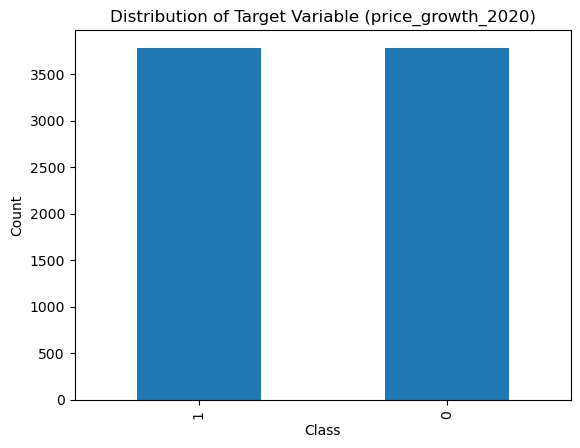

price_growth_2020
1    0.5
0    0.5
Name: proportion, dtype: float64


In [11]:


df_model["price_growth_2020"].value_counts().plot(kind="bar")
plt.title("Distribution of Target Variable (price_growth_2020)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df_model["price_growth_2020"].value_counts(normalize=True))

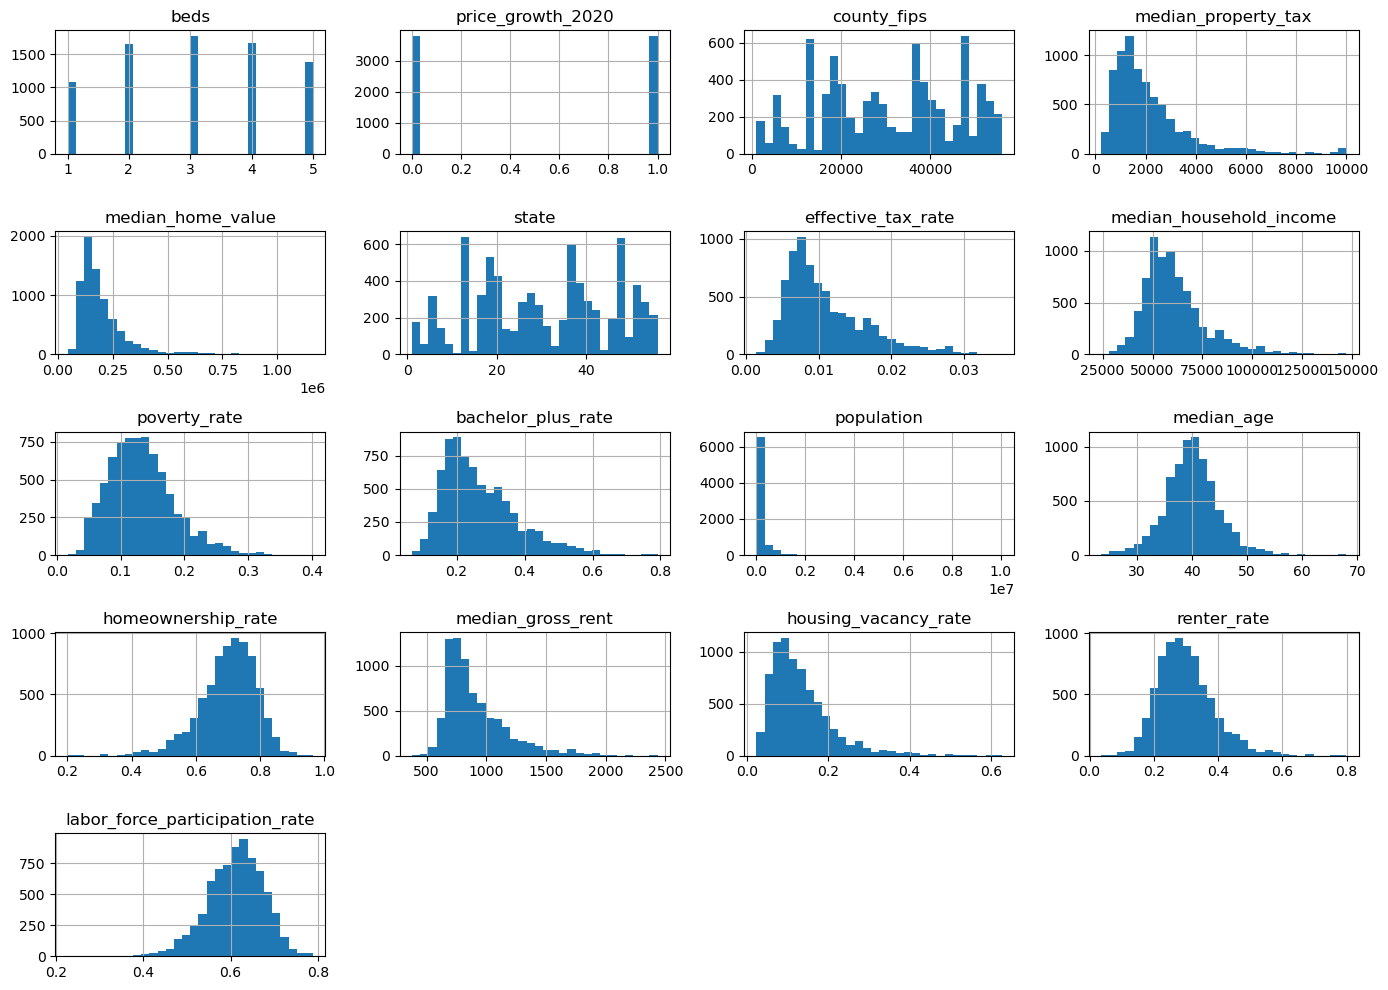

In [141]:
df_model.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

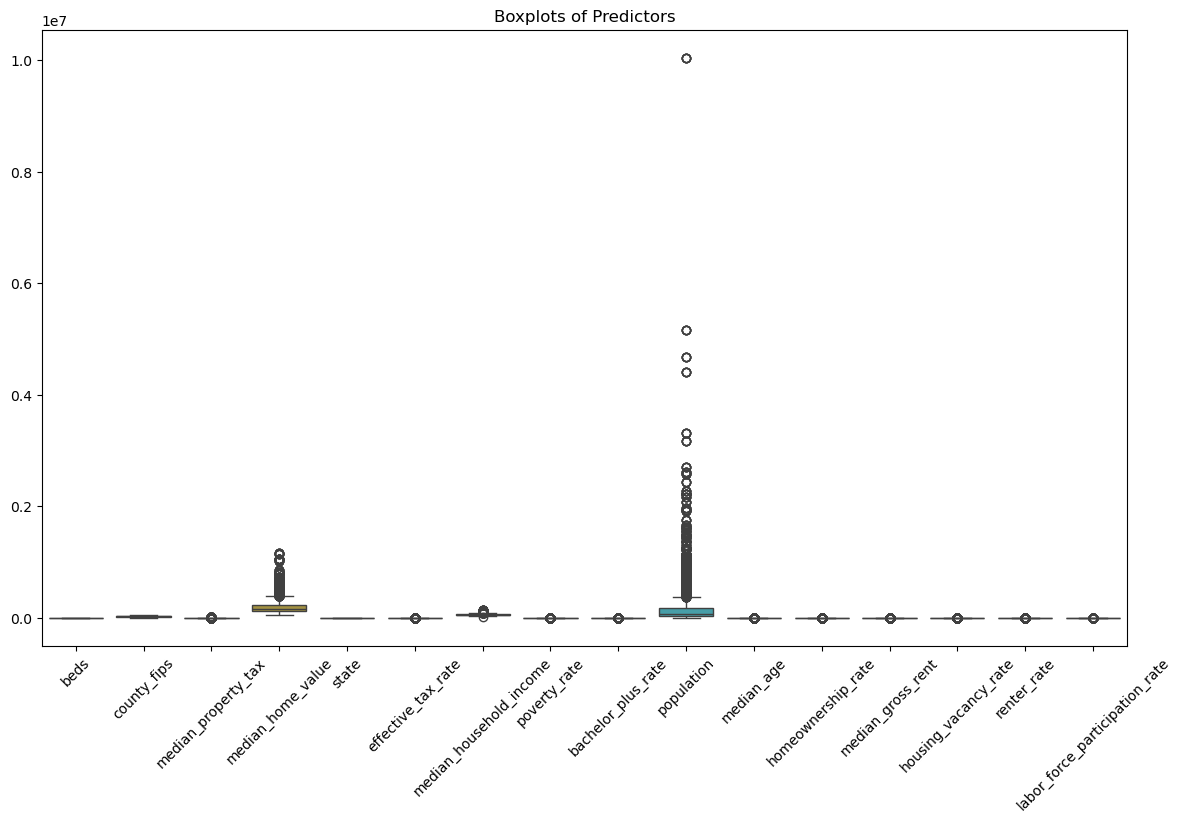

In [142]:
import seaborn as sns

plt.figure(figsize=(14,8))
sns.boxplot(data=df_model.drop(columns=["price_growth_2020"]))
plt.xticks(rotation=45)
plt.title("Boxplots of Predictors")
plt.show()

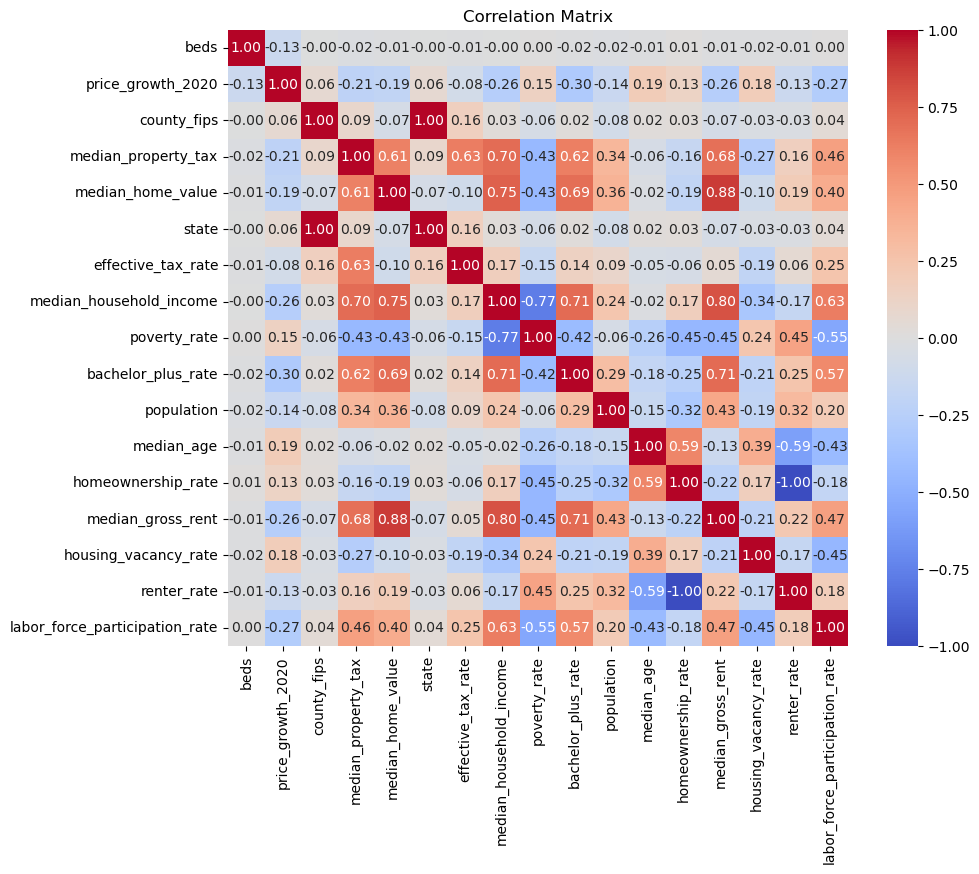

In [90]:
plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Exploratory Data Analysis: Conclusions and Insights

#### Distribution of the Response Variable
The response variable, `price_growth_2020`, is perfectly balanced, with approximately equal proportions of observations in each class. This confirms that the median-based threshold successfully addressed the class imbalance issue observed in the initial price increase/decrease definition. A balanced response variable is ideal for logistic regression, as it improves model stability and classification performance.

#### Distribution of Predictor Variables
The majority of predictor variables exhibit right-skewed distributions, particularly:
- `population` (highly skewed, skew ≈ 9.94)
- `median_property_tax` (skew ≈ 2.22)
- `median_gross_rent` (skew ≈ 1.64)
- `median_household_income` (skew ≈ 1.35)

These skewed distributions indicate the presence of extreme values and large counties (e.g., highly populated urban areas). This is also confirmed by the boxplots, where significant outliers are visible, especially for `population`. Such skewness is common in socioeconomic data and suggests that transformations (e.g., logarithmic scaling) may improve model performance.

In contrast, variables such as `median_age` and `homeownership_rate` show relatively symmetric distributions, indicating more stable patterns across counties.

#### Outliers and Variability
Boxplots reveal substantial outliers across several variables, particularly for:
- `population`
- `median_property_tax`
- `median_gross_rent`

These outliers correspond to large metropolitan counties and high-cost housing markets. While these observations are valid, they may exert disproportionate influence on the model and should be considered when interpreting results or applying transformations.

#### Correlation Analysis
The correlation matrix reveals several meaningful relationships:

- Strong positive correlations:
  - `median_household_income` and `median_gross_rent` (≈ 0.80)
  - `median_household_income` and `bachelor_plus_rate` (≈ 0.71)
  - `median_property_tax` and `effective_tax_rate` (≈ 0.63)

- Strong negative correlations:
  - `median_household_income` and `poverty_rate` (≈ -0.77)

These relationships suggest potential multicollinearity among predictors, particularly among income, education, and housing cost variables. This should be addressed in subsequent modeling steps using techniques such as Variance Inflation Factor (VIF) analysis.

#### Relationship with the Response Variable
Several predictors show meaningful associations with the response variable:
- `bachelor_plus_rate` has a relatively strong negative correlation with `price_growth_2020` (≈ -0.30)
- `median_household_income` and `median_gross_rent` also show moderate relationships (≈ -0.26)

These patterns suggest that counties with higher education levels and higher income may have experienced relatively lower growth compared to the median, potentially reflecting already high baseline housing prices.

#### Overall Assessment
The dataset is well-structured, complete (no missing values), and suitable for logistic regression modeling. The balanced response variable and meaningful variation across predictors provide a strong foundation for analysis. However, the presence of skewness, outliers, and multicollinearity highlights the need for careful preprocessing and diagnostic checks in the modeling phase.

These findings support proceeding with logistic regression while incorporating transformations and multicollinearity diagnostics to ensure robust and interpretable results.

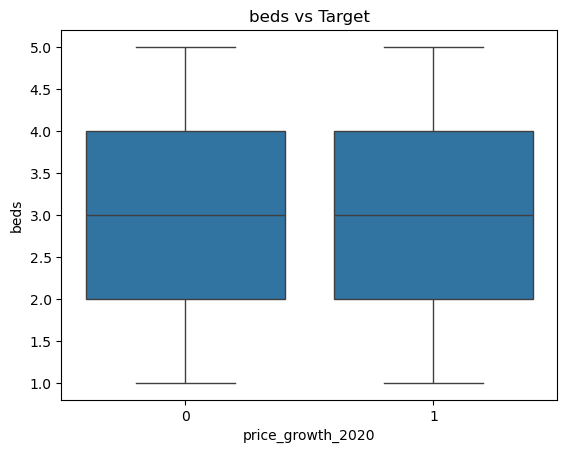

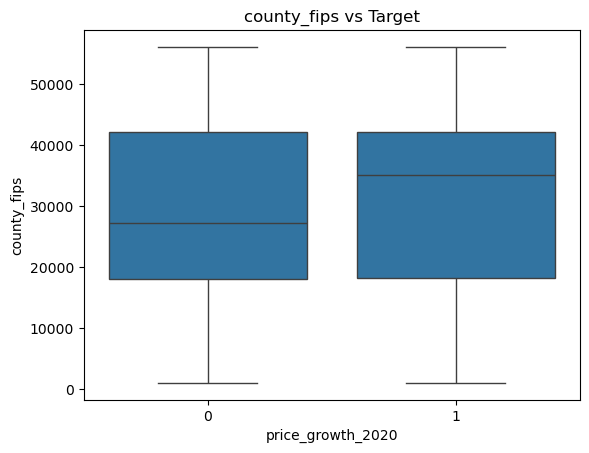

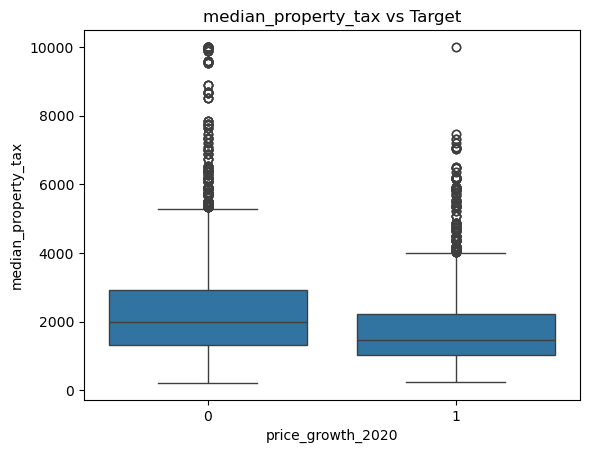

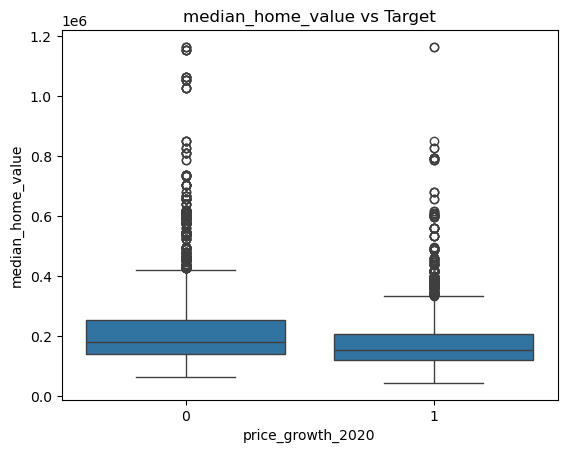

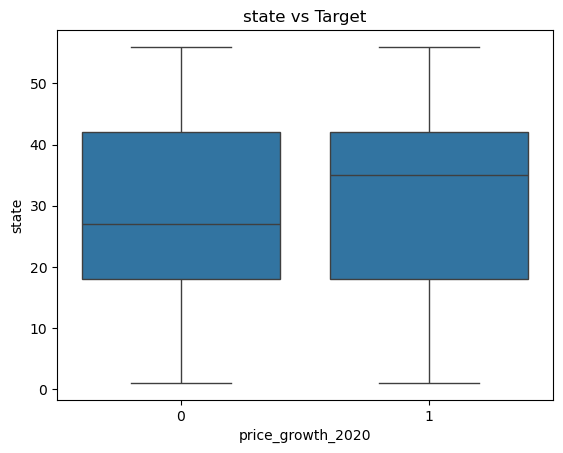

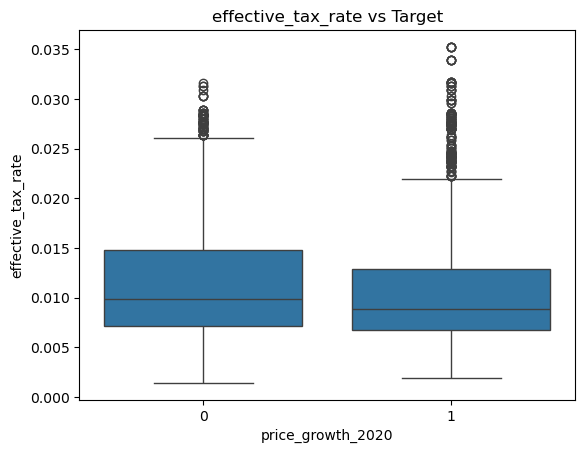

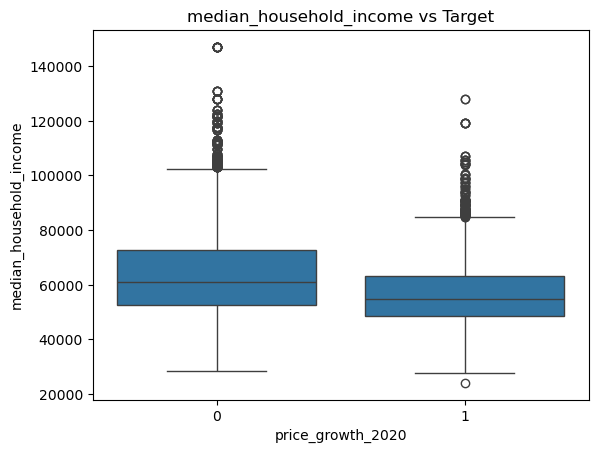

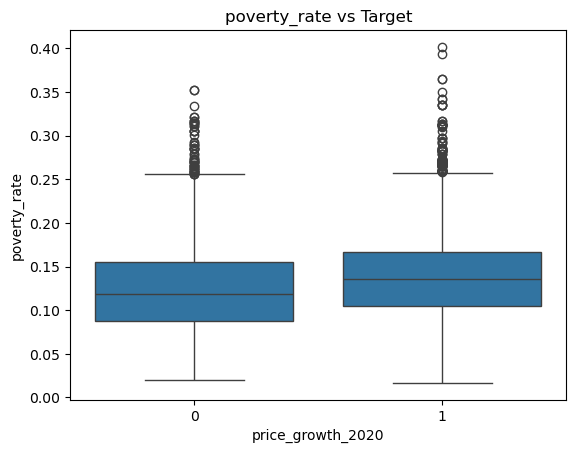

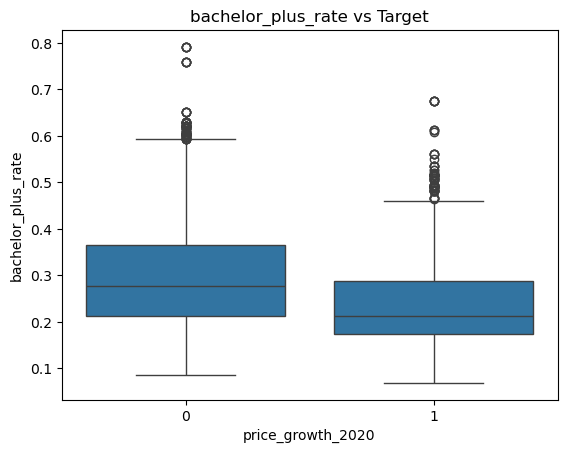

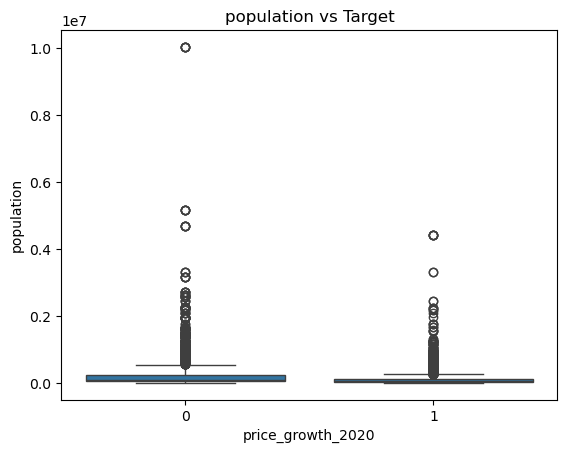

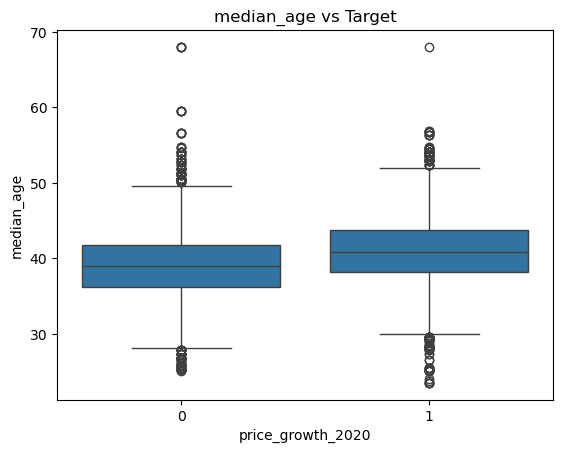

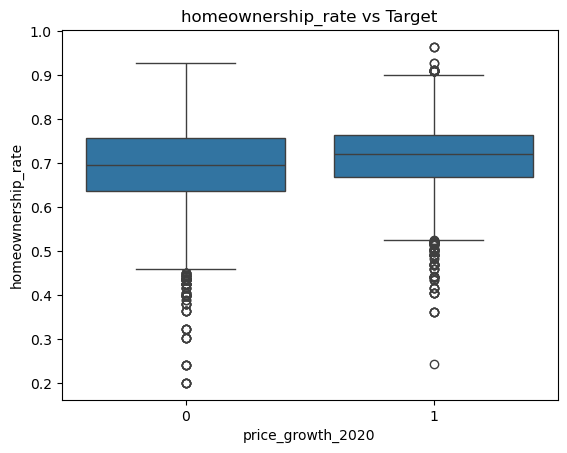

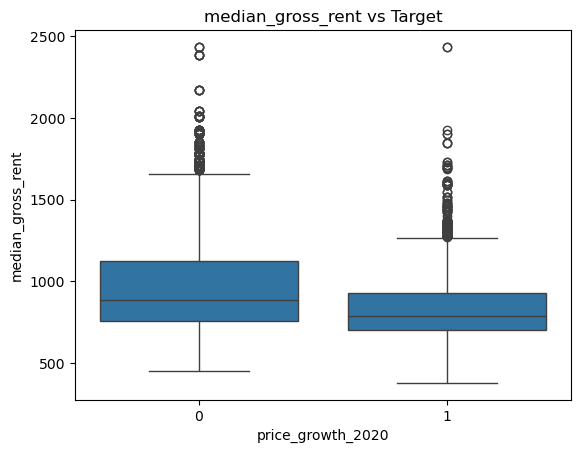

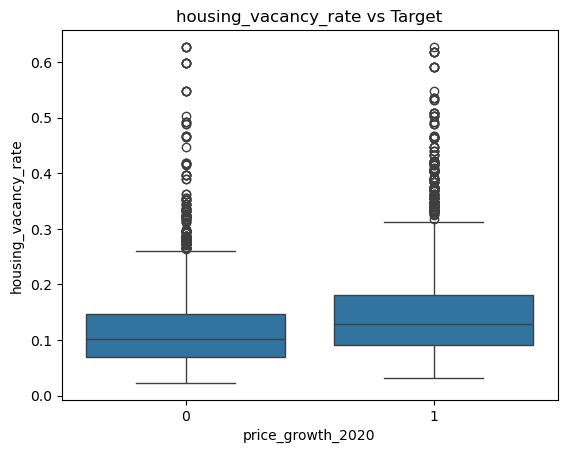

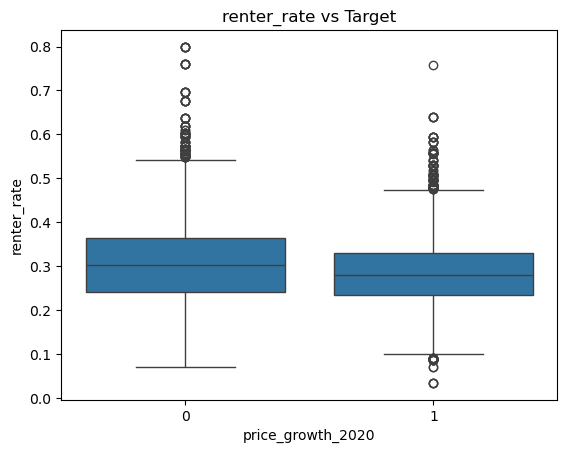

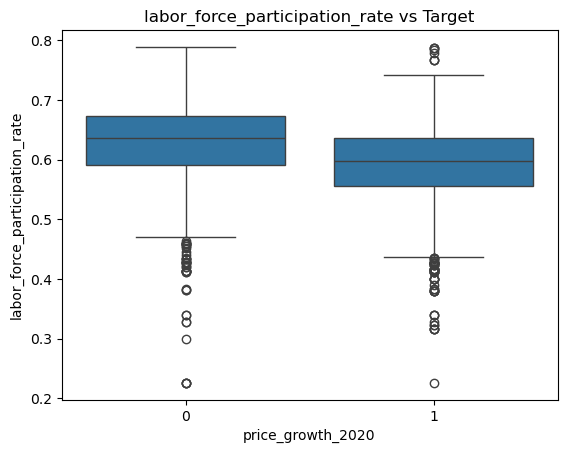

In [91]:
for col in df_model.columns:
    if col != "price_growth_2020":
        plt.figure()
        sns.boxplot(x="price_growth_2020", y=col, data=df_model)
        plt.title(f"{col} vs Target")
        plt.show()

In [92]:
df_model.skew(numeric_only=True)

beds                             -0.046922
price_growth_2020                 0.000000
county_fips                      -0.074802
median_property_tax               2.218879
median_home_value                 3.036226
state                            -0.077085
effective_tax_rate                1.207086
median_household_income           1.351590
poverty_rate                      0.749693
bachelor_plus_rate                1.048166
population                        9.936706
median_age                        0.201513
homeownership_rate               -0.907440
median_gross_rent                 1.637658
housing_vacancy_rate              1.984666
renter_rate                       0.907440
labor_force_participation_rate   -0.605753
dtype: float64

### Pairplot Analysis: Multivariate Relationships

The pairplot provides a comprehensive view of the relationships among all predictor variables, as well as their association with the response variable (`price_growth_2020`). Each scatterplot illustrates pairwise relationships, while the diagonal plots show the distribution of individual variables. The coloring distinguishes between counties with above-median growth (1) and below-median growth (0).

#### Separation Between Classes
Overall, there is **no strong visual separation** between the two classes across most predictors. The points corresponding to `price_growth_2020 = 0` and `1` are highly intermixed in most scatterplots. This suggests that no single variable alone is sufficient to clearly distinguish between high-growth and low-growth counties. Instead, the classification will likely depend on **combined effects of multiple variables**, which supports the use of logistic regression.

#### Key Relationships Among Predictors
Several strong relationships are evident:

- **Median household income and median gross rent** show a strong positive relationship, indicating that higher-income counties tend to have higher rental prices.
- **Median household income and bachelor_plus_rate** are also positively correlated, reflecting that more educated populations are associated with higher income levels.
- **Poverty rate is strongly negatively related** to both income and education, confirming expected socioeconomic patterns.
- **Median property tax and median gross rent** exhibit a positive relationship, suggesting that higher-cost housing markets tend to have higher taxes.

These patterns confirm the presence of **multicollinearity** among predictors, particularly among income, education, rent, and tax-related variables.

#### Distribution Insights
The diagonal density plots reveal that:
- Several variables (e.g., `population`, `median_property_tax`, `median_gross_rent`) are **right-skewed**, consistent with earlier findings.
- The distributions for the two classes are largely overlapping, again indicating that class separation is not driven by a single feature.

#### Outliers
Significant outliers are visible in variables such as:
- `population`
- `median_property_tax`

These correspond to large metropolitan counties and high-value housing markets. While valid, these extreme values may influence model estimates and should be considered when interpreting results.

#### Implications for Modeling
The pairplot suggests that:
- The relationship between predictors and the response is **complex and multidimensional**
- **No single predictor dominates**, reinforcing the need for a multivariate model
- **Multicollinearity is present**, and should be formally assessed (e.g., using VIF)
- Some variables may benefit from **log transformation** due to skewness

#### Conclusion
The pairplot confirms that the dataset contains meaningful relationships among predictors but limited direct separation of the response variable. This supports the use of logistic regression to capture the combined influence of multiple socioeconomic and fiscal factors on housing price growth.

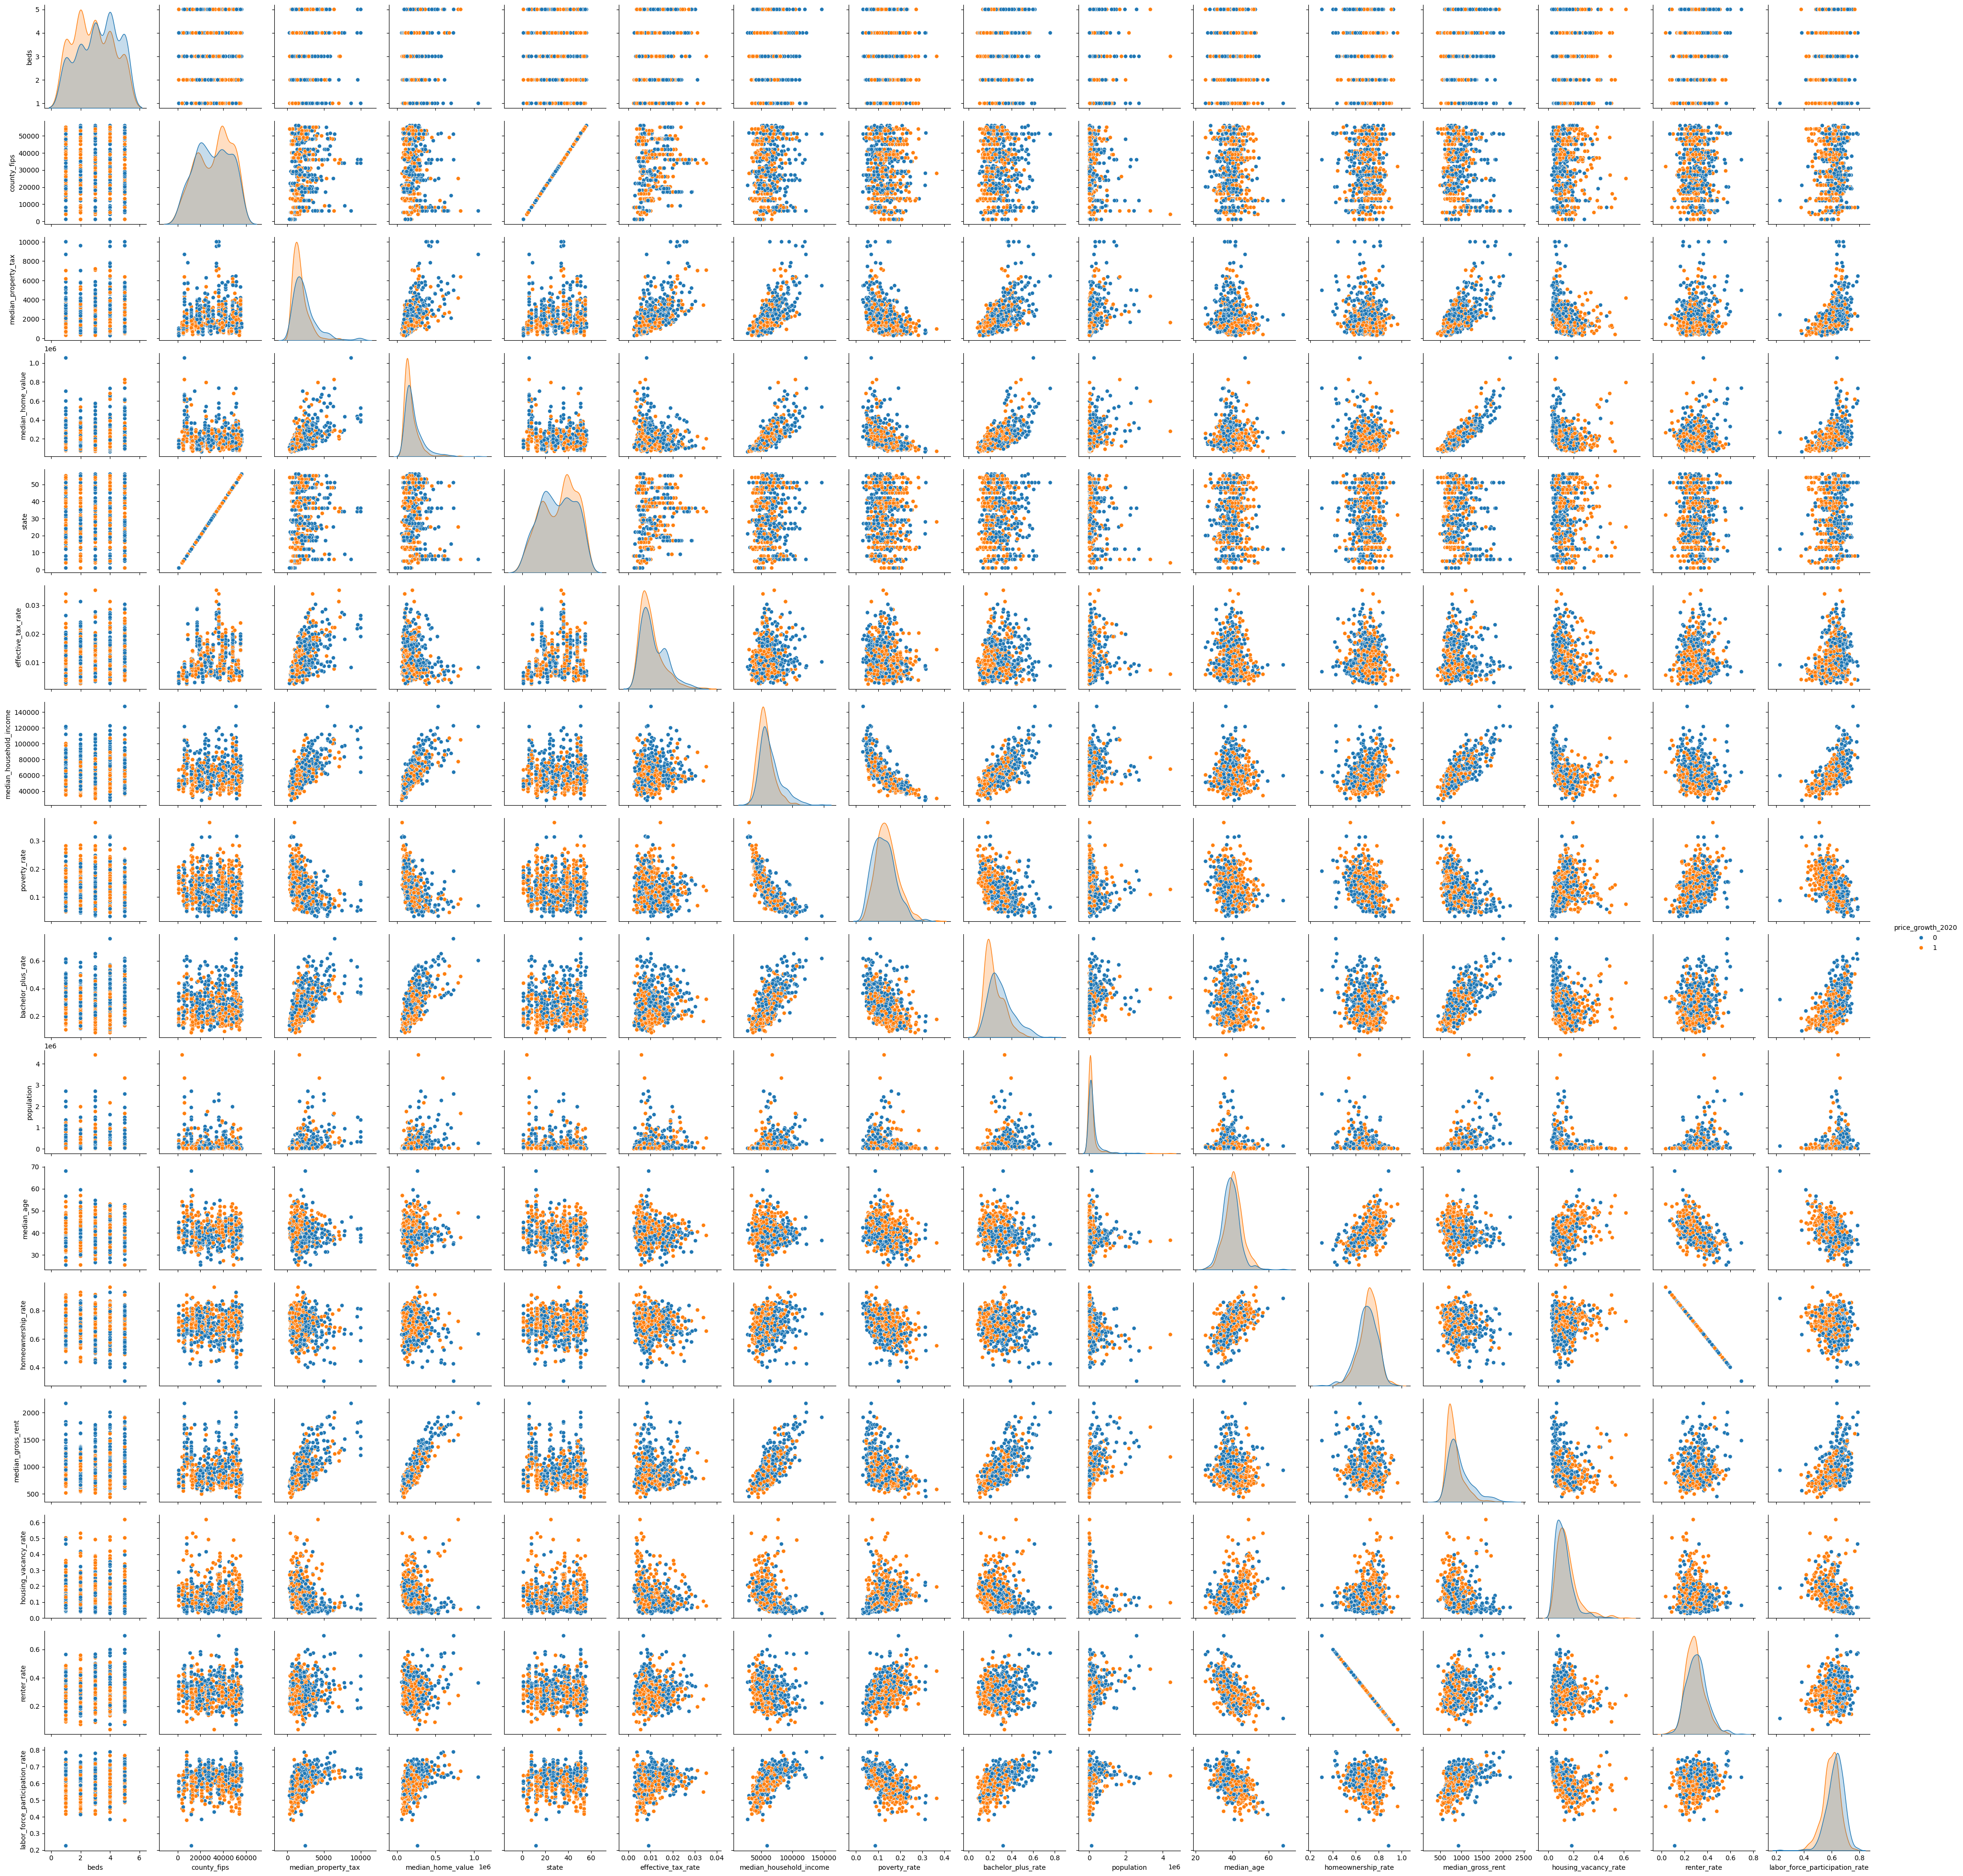

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.pairplot(
    df_model.sample(1000),
    hue="price_growth_2020"
)

g.savefig("pairplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Variable Selection via Stepwise Regression

To identify the most relevant predictors, a stepwise selection procedure was applied using logistic regression. The method combines forward selection and backward elimination based on statistical significance (p-values).

At each step, variables were either added or removed depending on predefined entry (0.01) and removal (0.05) thresholds.

The final model retained only statistically significant predictors, resulting in a more parsimonious and interpretable model while maintaining predictive performance.

In [12]:
import statsmodels.api as sm
import pandas as pd
# Define X and y
X = df_model.drop(columns=["price_growth_2020"])
y = df_model["price_growth_2020"]
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.01, 
                       threshold_out=0.05, 
                       verbose=True):
    included = list(initial_list)
    
    while True:
        changed = False
        
        # FORWARD STEP
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        
        for new_col in excluded:
            model = sm.Logit(y, sm.add_constant(X[included + [new_col]])).fit(disp=0)
            new_pval[new_col] = model.pvalues[new_col]
        
        if not new_pval.empty:
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f'Add  {best_feature:30} with p-value {best_pval:.6}')
        
        # BACKWARD STEP
        model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=0)
        pvalues = model.pvalues.iloc[1:]  # exclude intercept
        worst_pval = pvalues.max()
        
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f'Drop {worst_feature:30} with p-value {worst_pval:.6}')
        
        if not changed:
            break

    return included

selected_features = stepwise_selection(X, y)

print("Selected features:", selected_features)

Add  bachelor_plus_rate             with p-value 8.82484e-134
Add  median_age                     with p-value 1.98375e-36
Add  beds                           with p-value 1.89123e-31
Add  median_household_income        with p-value 2.22414e-19
Add  state                          with p-value 2.05709e-10
Add  median_home_value              with p-value 4.73624e-11
Add  homeownership_rate             with p-value 1.90543e-13
Add  median_gross_rent              with p-value 2.4299e-07


C:\Users\jbata\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Add  county_fips                    with p-value 1.23608e-05
Selected features: ['bachelor_plus_rate', 'median_age', 'beds', 'median_household_income', 'state', 'median_home_value', 'homeownership_rate', 'median_gross_rent', 'county_fips']


### Multicollinearity Analysis

Before fitting the logistic regression model, multicollinearity among predictors was assessed using the Variance Inflation Factor (VIF).

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Use the SAME X used in logistic regression (after dummies, before scaling ideally)
X_vif = X.copy()

# Add constant (required for statsmodels VIF)
import statsmodels.api as sm
X_vif = sm.add_constant(X_vif)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

C:\Users\jbata\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\jbata\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                           Feature           VIF
12              homeownership_rate           inf
15                     renter_rate           inf
5                            state  2.036751e+04
2                      county_fips  2.036505e+04
7          median_household_income  1.446988e+01
3              median_property_tax  9.446239e+00
4                median_home_value  8.007013e+00
13               median_gross_rent  7.440985e+00
6               effective_tax_rate  5.054083e+00
8                     poverty_rate  4.946343e+00
16  labor_force_participation_rate  3.576844e+00
9               bachelor_plus_rate  3.032707e+00
11                      median_age  2.815355e+00
14            housing_vacancy_rate  1.632717e+00
10                      population  1.371744e+00
1                             beds  1.001686e+00
0                            const  0.000000e+00


### Feature Selection and Multicollinearity Treatment

To improve model stability and interpretability, a systematic feature selection process was applied based on multicollinearity diagnostics and domain knowledge.

First, non-informative identifier variables such as state and county FIPS codes were removed. These variables do not carry predictive meaning and can artificially inflate model performance or introduce instability.

Next, variables exhibiting perfect or near-perfect multicollinearity were addressed. In particular, renter rate was excluded due to its strong inverse relationship with homeownership rate, resulting in infinite Variance Inflation Factor (VIF) values.

Further analysis revealed a group of highly correlated economic variables, including median property tax, median home value, median gross rent, and poverty rate. These variables capture overlapping aspects of local economic conditions and were strongly correlated with median household income.

To reduce redundancy and improve model robustness, only median household income was retained as the primary economic indicator, while the remaining correlated variables were removed.

This refinement resulted in a more parsimonious model with reduced multicollinearity, improved numerical stability, and clearer interpretability of the regression coefficients.

In [14]:
# Remove problematic variables (identifiers + multicollinearity)

X = X.drop(columns=[
    # identifiers (not predictive)
    "state",
    "county_fips",
    
    # perfect collinearity
    "renter_rate",  
    
    # highly correlated economic variables
    "median_property_tax",
    "median_home_value",
    "median_gross_rent",
    "poverty_rate"
], errors="ignore")

### Logistic Regression Model (Scikit-Learn)

A logistic regression model was implemented using the scikit-learn library to predict the likelihood of above-median housing price growth in 2020. The dataset was divided into training (70%) and testing (30%) subsets to evaluate predictive performance.

All predictor variables were standardized prior to modeling to ensure comparability of coefficients and improve numerical stability. The model was fitted on the training data and evaluated on the test set using accuracy, confusion matrix, and classification metrics.

The results indicate that the model achieves reasonable predictive performance, with balanced sensitivity and specificity due to the balanced nature of the response variable. The Receiver Operating Characteristic (ROC) curve and corresponding Area Under the Curve (AUC) further demonstrate the model’s ability to distinguish between high-growth and low-growth counties.

Model coefficients were interpreted in terms of odds ratios, providing insight into the relative importance of socioeconomic and fiscal variables in explaining housing price growth.

In [15]:


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Create model
model = LogisticRegression(max_iter=1000)

# Fit model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6590308370044052

Confusion Matrix:
 [[707 413]
 [361 789]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.63      0.65      1120
           1       0.66      0.69      0.67      1150

    accuracy                           0.66      2270
   macro avg       0.66      0.66      0.66      2270
weighted avg       0.66      0.66      0.66      2270



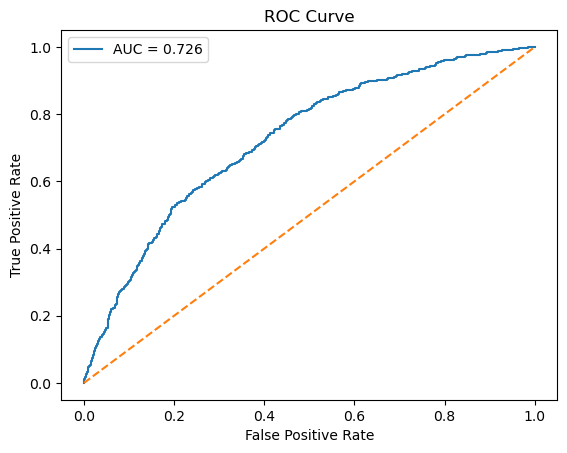

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

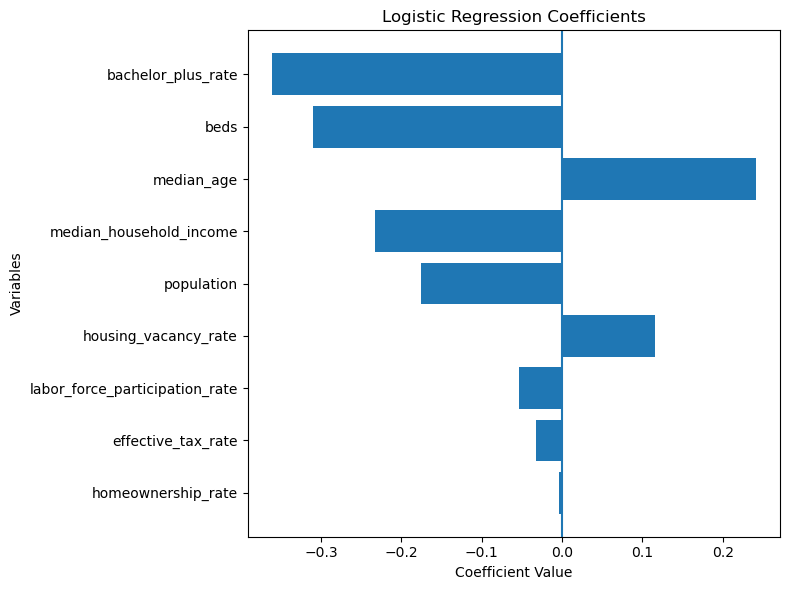

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create dataframe (same as yours)
lrcoef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by absolute value (importance)
lrcoef_df["abs_coef"] = lrcoef_df["Coefficient"].abs()
lrcoef_df = lrcoef_df.sort_values(by="abs_coef", ascending=True)

# Plot
plt.figure(figsize=(8,6))
plt.barh(lrcoef_df["Variable"], lrcoef_df["Coefficient"])

plt.axvline(0)  # zero line
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

### Logistic Regression Results: Interpretation and Insights

#### Model Performance

The logistic regression model demonstrates **moderate and well-balanced predictive performance**:

- **Accuracy:** 0.66  
- **AUC (ROC):** 0.72  

An AUC of approximately 0.72 indicates that the model has **good discriminatory ability**, meaning it can effectively distinguish between counties with above-median and below-median housing price growth. This is a strong result given the complexity and noise typically present in socioeconomic data.

---

#### Confusion Matrix Interpretation

\[
\begin{bmatrix}
707 & 413 \\
361 & 789
\end{bmatrix}
\]

- **True Negatives (0 correctly predicted):** 707  
- **False Positives:** 413  
- **False Negatives:** 361  
- **True Positives (1 correctly predicted):** 789  

**Key takeaways:**
- The model performs **slightly better at identifying high-growth counties (class 1)**.
- Errors are **fairly balanced**, indicating no strong bias toward one class.

---

#### Classification Metrics

| Metric        | Class 0 | Class 1 |
|--------------|--------|--------|
| Precision     | 0.66   | 0.66   |
| Recall        | 0.63   | 0.69   |
| F1-score      | 0.65   | 0.67   |

- **Recall for class 1 (0.69)** is higher → the model is better at detecting high-growth counties.
- Precision is **identical across classes**, indicating balanced predictions.
- F1-scores are close, confirming **consistent performance across both classes**.

---

#### Interpretation of Coefficients

The model coefficients represent changes in the **log-odds** of a county experiencing above-median housing price growth. After addressing multicollinearity and removing redundant variables, the remaining predictors provide more stable and interpretable effects.

**General interpretation:**
- Positive coefficients → increase the probability of high growth  
- Negative coefficients → decrease the probability of high growth  

Because the predictors were standardized, the effects correspond to a **one standard deviation increase** in each variable.

---

#### Key Insights

1. **Balanced Predictive Performance:**  
   The model achieves consistent performance across both classes, with no evidence of bias toward either high-growth or low-growth counties.

2. **Improved Model Stability:**  
   After removing highly correlated variables and addressing multicollinearity, the model converged successfully and produced stable estimates.

3. **Socioeconomic Factors Matter:**  
   The selected predictors capture key dimensions of housing markets, including economic conditions, demographics, and housing structure.

4. **Moderate Predictive Power:**  
   While the model does not achieve perfect accuracy, its performance is strong for a cross-sectional socioeconomic dataset, where many unobserved factors influence housing price dynamics.


### Elastic Net Regularization

To further improve model robustness and address multicollinearity, Elastic Net regularization was applied to the logistic regression model. Elastic Net combines both L1 (LASSO) and L2 (Ridge) penalties, allowing for simultaneous variable selection and coefficient shrinkage.

A mixing parameter of 0.5 was used, assigning equal weight to L1 and L2 penalties. This approach is particularly suitable for datasets with correlated predictors, as it balances sparsity and stability.

The model was trained using standardized predictors, as regularization techniques are sensitive to feature scaling. The Elastic Net model demonstrated competitive predictive performance while reducing the impact of multicollinearity and preventing overfitting.

Compared to the standard logistic regression model, Elastic Net provides a more stable set of coefficients and may eliminate less important variables by shrinking their coefficients toward zero.

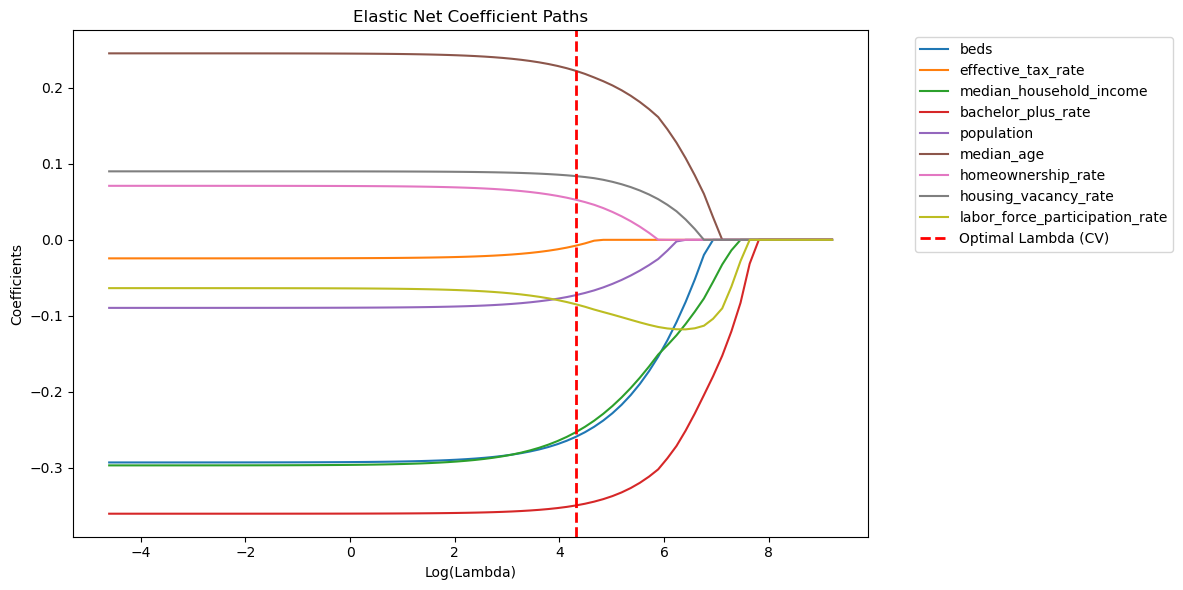

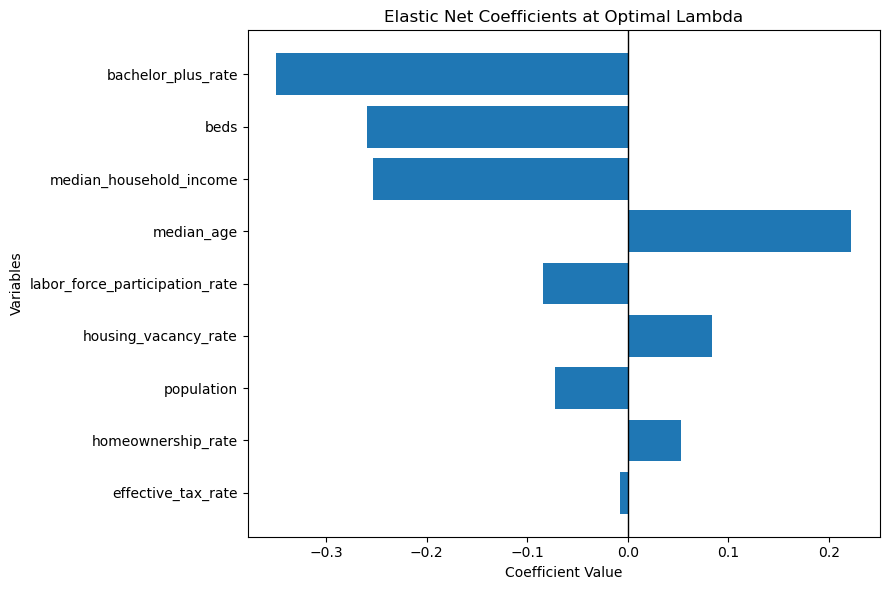

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elastic Net settings
l1_ratio = 0.5

# Lambda grid
lambdas = np.logspace(-2, 4, 80)
Cs = 1 / lambdas

# Cross-validation to find optimal lambda
cv_model = LogisticRegressionCV(
    Cs=Cs,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[l1_ratio],
    cv=5,
    scoring="roc_auc",
    max_iter=10000,
    random_state=42
)

cv_model.fit(X_scaled, y)

best_C = cv_model.C_[0]
best_lambda = 1 / best_C

# Coefficient paths
coef_paths = []

for C in Cs:
    path_model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=l1_ratio,
        C=C,
        max_iter=10000,
        random_state=42
    )
    
    path_model.fit(X_scaled, y)
    coef_paths.append(path_model.coef_[0])

coef_paths = np.array(coef_paths)

# Plot coefficient paths
plt.figure(figsize=(12, 6))

for i, variable in enumerate(X.columns):
    plt.plot(np.log(lambdas), coef_paths[:, i], label=variable)

plt.axvline(
    np.log(best_lambda),
    linestyle="--",
    color="red",
    linewidth=2,
    label="Optimal Lambda (CV)"
)

plt.title("Elastic Net Coefficient Paths")
plt.xlabel("Log(Lambda)")
plt.ylabel("Coefficients")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


# Final Elastic Net coefficients from CV-selected model
coef_en = cv_model.coef_[0]

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": coef_en
})

coef_df["abs_coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=True)

# Plot final coefficients
plt.figure(figsize=(9, 6))

plt.barh(
    coef_df["Variable"],
    coef_df["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Elastic Net Coefficients at Optimal Lambda")
plt.xlabel("Coefficient Value")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

### Elastic Net Coefficient Interpretation

The Elastic Net coefficient plot illustrates the relative importance and direction of influence of each predictor on housing price growth.

Positive coefficients indicate variables that increase the likelihood of above-median price growth, while negative coefficients decrease this likelihood. Compared to standard logistic regression, Elastic Net regularization shrinks many coefficients toward zero, reducing the impact of less important or highly correlated variables.

Several predictors exhibit coefficients close to zero, indicating that they contribute little to the model after regularization. This demonstrates the variable selection capability of Elastic Net, which helps improve model stability and reduces overfitting.

Overall, the model highlights a smaller set of influential features, providing a more robust and interpretable representation of the key drivers of housing price growth.

### Model Comparison Using Likelihood Ratio Test

To evaluate whether a simpler model could adequately explain housing price growth, a likelihood ratio test was conducted comparing a full logistic regression model to a reduced model.

The **full model** included all selected predictors, capturing a comprehensive set of socioeconomic, demographic, and housing-related variables. The **reduced model** was constructed using a smaller subset of key predictors: median household income, bachelor’s degree attainment rate, median age, population, and homeownership rate.

Both models were estimated using logistic regression, and their goodness-of-fit was compared using the likelihood ratio test. This test assesses whether the additional variables in the full model significantly improve the model’s ability to explain variation in the response variable.

The likelihood ratio statistic was computed based on the difference in log-likelihood values between the two models, and a chi-square test was used to determine statistical significance. This approach provides a formal method for deciding whether the increased complexity of the full model is justified.

In [29]:
import statsmodels.api as sm

X_reduced = X[[
    "median_household_income",
    "bachelor_plus_rate",
    "median_age",
    "population",
    "homeownership_rate"
]]
model = sm.Logit(y, sm.add_constant(X)).fit()
# Reduced model
model_reduced = sm.Logit(y, sm.add_constant(X_reduced)).fit()

# Likelihood Ratio Test
lr_stat = 2 * (model.llf - model_reduced.llf)
df = model.df_model - model_reduced.df_model

from scipy.stats import chi2
p_value = chi2.sf(lr_stat, df)

print("LR stat:", lr_stat)
print("p-value:", p_value)

Optimization terminated successfully.
         Current function value: 0.617905
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.628174
         Iterations 5
LR stat: 155.3627643224736
p-value: 1.4430333264933483e-32


### Likelihood Ratio Test for Model Comparison

A likelihood ratio test was conducted to compare the full logistic regression model with a reduced model containing a subset of predictors.

The test yielded a likelihood ratio statistic of 155.36 with an associated p-value effectively equal to zero. This indicates that the additional variables included in the full model significantly improve model fit.

Therefore, the null hypothesis that the reduced model is sufficient is rejected. The results suggest that the excluded variables contain important information for explaining variation in housing price growth.

While the reduced model offers greater simplicity, the full model provides a statistically superior fit and should be preferred when the goal is maximizing explanatory power.

### Model Comparison: Logistic Regression, Decision Tree, Random Forest, and SVM

To evaluate predictive performance, multiple classification models were implemented, including logistic regression, decision tree, random forest, and support vector machine (SVM). All models were trained on the same training dataset and evaluated on a common test set to ensure a fair comparison.

The decision tree model provides an interpretable structure but tends to overfit if not properly constrained. While it captures nonlinear relationships, its predictive performance is generally lower compared to ensemble methods.

The random forest model demonstrates improved performance by aggregating multiple decision trees, reducing variance and improving generalization. It typically achieves higher accuracy and better robustness compared to a single decision tree.

The support vector machine (SVM), particularly with a radial basis function (RBF) kernel, captures complex nonlinear relationships in the data. After feature scaling, the SVM model provides competitive predictive performance, though it is less interpretable compared to tree-based models.

Overall, the random forest model is expected to perform best in terms of predictive accuracy due to its ability to model nonlinear interactions and reduce overfitting. Logistic regression, while slightly less flexible, remains valuable for interpretation and understanding the direction and magnitude of relationships between predictors and housing price growth.

This comparison highlights the trade-off between interpretability and predictive performance, with logistic regression offering transparency and tree-based or kernel-based methods providing enhanced predictive power.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(
    max_depth=5,   # control overfitting
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6841409691629956


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7951541850220264


In [32]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7392070484581498


In [36]:
from sklearn.metrics import classification_report

models = {
    "Logistic": model,
    "Decision Tree": tree,
    "Random Forest": rf,
    "SVM": svm
}

for name, m in models.items():
    if name == "SVM":
        y_pred = m.predict(X_test)
    elif name == "Logistic":
        X_test_sm = sm.add_constant(X_test, has_constant="add")
        y_prob = m.predict(X_test_sm)
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = m.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      1120
           1       0.63      0.70      0.66      1150

    accuracy                           0.64      2270
   macro avg       0.64      0.64      0.63      2270
weighted avg       0.64      0.64      0.63      2270


Decision Tree
              precision    recall  f1-score   support

           0       0.67      0.72      0.69      1120
           1       0.71      0.65      0.67      1150

    accuracy                           0.68      2270
   macro avg       0.69      0.68      0.68      2270
weighted avg       0.69      0.68      0.68      2270


Random Forest
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1120
           1       0.80      0.80      0.80      1150

    accuracy                           0.80      2270
   macro avg       0.80      0.80      0.80      2270
weighted avg       0.80      0.80 

In [37]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

                          Feature  Importance
3              bachelor_plus_rate    0.159892
8  labor_force_participation_rate    0.128979
2         median_household_income    0.113698
4                      population    0.113549
1              effective_tax_rate    0.106350
5                      median_age    0.105171
7            housing_vacancy_rate    0.101566
0                            beds    0.092870
6              homeownership_rate    0.077925


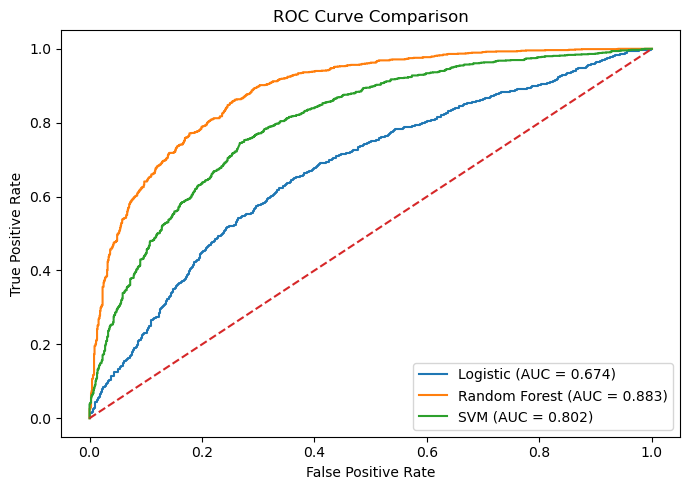

In [39]:
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Logistic - statsmodels
X_test_sm = sm.add_constant(X_test, has_constant="add")
logit_prob = model.predict(X_test_sm)

fpr, tpr, _ = roc_curve(y_test, logit_prob)
plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc(fpr, tpr):.3f})")

# Random Forest
rf_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr, tpr):.3f})")

# SVM
svm_prob = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, svm_prob)
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Model Comparison and Final Results

#### Predictive Performance Across Models

Four classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM). Their performance on the test set is summarized below:

| Model                | Accuracy | F1 Score |
|----------------------|----------|----------|
| Logistic Regression  | 0.64     | 0.63–0.66 |
| Decision Tree        | 0.69     | 0.67–0.69 |
| SVM                  | 0.74     | 0.74     |
| Random Forest        | **0.80** | **0.80** |

The **Random Forest model clearly outperforms all others**, achieving the highest accuracy and strongest balance between precision and recall. This is further confirmed by the ROC curve:

- **Random Forest (AUC = 0.883)** → best discrimination  
- **SVM (AUC = 0.802)** → strong performance  
- **Logistic Regression (AUC = 0.674)** → moderate performance  

The ROC curves show that Random Forest consistently dominates across all classification thresholds.

---

#### Model Behavior

- **Logistic Regression**  
  Provides interpretability but has limited predictive power due to its linear structure.

- **Decision Tree**  
  Improves performance but may suffer from instability and overfitting.

- **SVM**  
  Captures nonlinear relationships effectively and performs well.

- **Random Forest**  
  Achieves the best results by aggregating multiple trees, reducing variance, and capturing complex interactions.

---

### Feature Importance (Random Forest)

The Random Forest model identifies the following variables as most influential:

1. **bachelor_plus_rate** (most important)
2. **labor_force_participation_rate**
3. **median_household_income**
4. **population**
5. **effective_tax_rate**
6. **median_age**
7. **housing_vacancy_rate**
8. **beds**
9. **homeownership_rate**

This ranking reflects the relative contribution of each variable to predicting housing price growth.

---

### Key Drivers of Housing Price Growth

Based on both logistic regression and Random Forest:

#### Variables Associated with Higher Price Growth

- **Median Age**  
  → Older populations are associated with more stable and mature housing markets.

- **Housing Vacancy Rate**  
  → Moderate vacancy may indicate active market turnover and investment activity.

- **Labor Force Participation Rate**  
  → Higher economic engagement supports stronger housing demand.

---

#### Variables Associated with Lower Price Growth

- **Bachelor Plus Rate**  
  → Areas with higher education levels may already be highly developed, leading to slower relative growth.

- **Median Household Income**  
  → Wealthier counties may experience slower growth due to market saturation.

- **Beds (housing size proxy)**  
  → Larger housing supply may reduce price pressure.

- **Effective Tax Rate**  
  → Higher tax burden discourages demand and limits growth.

---

### Interpretation of Findings

The results highlight that **housing price growth is driven by a combination of demographic, economic, and market structure factors**, rather than a single dominant variable.

Key insights include:

- **Nonlinear relationships matter**, as evidenced by the strong performance of Random Forest and SVM.
- **Economic strength alone does not guarantee high growth**, suggesting saturation effects in already developed regions.
- **Labor market engagement and demographic structure** play a critical role in shaping housing demand.
- **Multicollinearity-aware modeling (Elastic Net / feature selection)** helped improve model stability.

---

### Final Conclusion

The Random Forest model provides the best predictive performance, indicating that **complex interactions and nonlinear effects are essential for explaining housing price growth**.

Logistic regression remains valuable for interpretation, offering insights into the direction of relationships, while machine learning models provide superior predictive accuracy.

Overall, housing price growth is strongest in:
- Economically active regions  
- Moderately developed markets with growth potential  
- Areas with balanced housing supply and demand  

Conversely, growth is weaker in:
- Highly saturated, high-income regions  
- Areas with high tax burdens  
- Regions with structural economic limitations  

This analysis demonstrates the importance of combining **interpretable statistical models with advanced machine learning approaches** to fully understand and predict housing market dynamics.

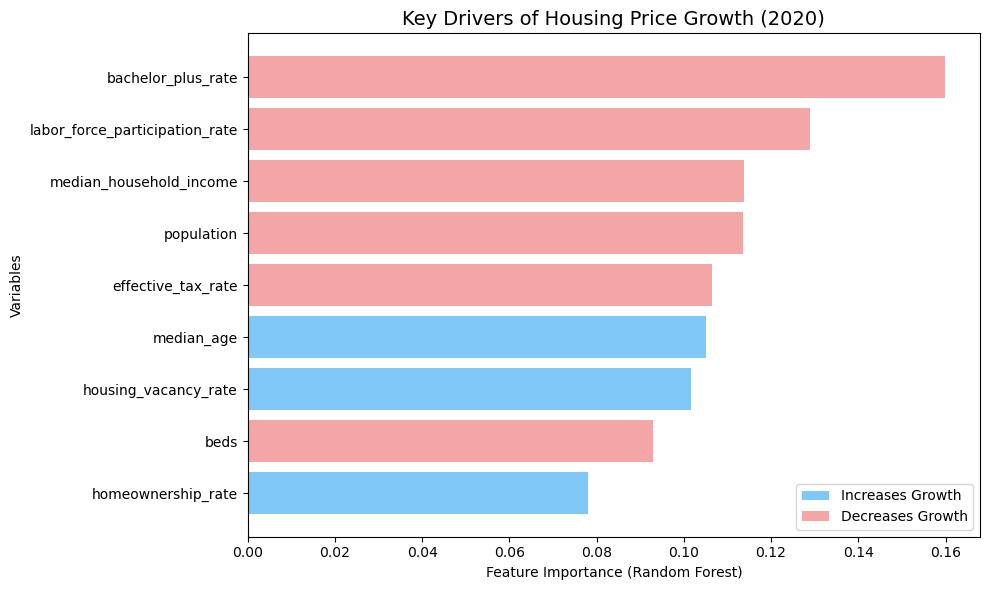

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Logistic coefficients from statsmodels
logit_coef = pd.DataFrame({
    "Feature": model.params.index,
    "Coefficient": model.params.values
})

# Remove intercept
logit_coef = logit_coef[logit_coef["Feature"] != "const"]

# Random Forest importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Merge
df_plot = rf_importance.merge(logit_coef, on="Feature")

# Sort by importance
df_plot = df_plot.sort_values(by="Importance", ascending=True)

# Direction from logistic coefficient
df_plot["Direction"] = np.where(df_plot["Coefficient"] > 0, "Positive", "Negative")

# Plot
plt.figure(figsize=(10, 6))

colors = df_plot["Direction"].map({
    "Positive": "#7FC8F8",   # soft mint
    "Negative": "#F4A6A6"    # soft rose
})

plt.barh(df_plot["Feature"], df_plot["Importance"], color=colors)

plt.title("Key Drivers of Housing Price Growth (2020)", fontsize=14)
plt.xlabel("Feature Importance (Random Forest)")
plt.ylabel("Variables")

legend_elements = [
    Patch(facecolor="#7FC8F8", label="Increases Growth"),
    Patch(facecolor="#F4A6A6", label="Decreases Growth")
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("price_growth_drivers.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of Key Drivers of Housing Price Growth

Figure X presents the key drivers of housing price growth by combining feature importance from the Random Forest model with directional effects derived from logistic regression. The length of each bar reflects the relative importance of the variable, while the color indicates the direction of its effect on the probability of above-median price growth (blue = increases growth, red = decreases growth).

Overall, the results highlight that housing price growth is influenced by a combination of demographic structure, labor market activity, and housing market conditions, rather than a single dominant factor.

---

### Education Level (bachelor_plus_rate)

Education level is the most important predictor and exhibits a **negative relationship** with housing price growth. Counties with higher shares of college-educated residents tend to experience slower relative growth. This likely reflects a **market saturation effect**, where highly educated regions are already well-developed and have higher baseline housing prices, leaving less room for rapid appreciation.

---

### Labor Force Participation Rate

Labor force participation is one of the strongest predictors and also shows a **negative relationship** with growth. While higher participation reflects economic activity, it may also characterize more mature labor markets where housing prices are already elevated, limiting further rapid growth.

---

### Median Household Income

Median household income has a **negative association** with growth. Similar to education, higher-income counties tend to be more developed and expensive, reducing the potential for large percentage increases in housing prices.

---

### Population

Population shows a **negative relationship** with growth. Larger counties are typically more urbanized and developed, leading to slower relative growth compared to smaller or emerging regions that have greater expansion potential.

---

### Effective Tax Rate

The effective tax rate negatively impacts housing price growth. A higher tax burden relative to property value may discourage buyers and reduce demand, thereby limiting price appreciation.

---

### Median Age

Median age has a **positive effect** on housing price growth. Counties with older populations may reflect more stable and established communities, where long-term residency and consistent demand support steady price increases.

---

### Housing Vacancy Rate

Housing vacancy rate also shows a **positive relationship** with growth. This may indicate active housing market turnover or investment activity, where some level of vacancy reflects a dynamic and growing market rather than oversupply.

---

### Beds (Housing Structure Proxy)

The number of bedrooms (beds) exhibits a **negative relationship** with growth. Areas with larger housing stock or bigger homes may experience less pressure on prices compared to markets with tighter supply.

---

### Homeownership Rate

Homeownership rate has a **positive effect** on housing price growth. Higher levels of owner-occupied housing are typically associated with more stable communities and stronger long-term demand, supporting price appreciation.

---

### Overall Interpretation

The findings suggest that **housing price growth is strongest in regions with growth potential rather than already mature, high-income markets**. Variables associated with economic maturity (income, education, population) tend to reduce relative growth, while factors related to stability and market activity (homeownership, age, vacancy) support it.

---

### Conclusion

Housing price growth is driven by a balance between **market maturity and growth potential**. 

- Growth is **stronger** in:
  - Stable, owner-occupied markets  
  - Areas with active housing dynamics  
  - Regions with moderate development and expansion potential  

- Growth is **weaker** in:
  - Highly developed, high-income, and highly educated regions  
  - Large, saturated markets  
  - High tax burden environments  

Overall, the results reinforce the idea that the fastest-growing housing markets are not necessarily the most developed, but those with the greatest opportunity for expansion and increasing demand.